# Imports

In [16]:
import os
import h5py
import numpy as np
from scipy.stats import mode, sem
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import pandas as pd

# Functions

### Visualization of features

In [ ]:
def visualize_features(
    average_dict, 
    error_dict, 
    feature_name, 
    feature_index, 
    state_names = ['Wake', 'N1', 'N2', 'N3', 'REM'],
    colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick'],
    title_id="All subjects", 
    file_id="complete-dataset"
):
    """
    Creates a barplot with the average of a single feature per state 
    and saves it to specified output location.

    Parameters:
        average_dict (dict): Dictionary with feature averages per state.
        error_dict (dict): Dictionary with feature errors per state.
        feature_name (str): Name of current feature to visualize.
        feature_index (int): Index of current feature to visualize.
        colors (list): list of colors (same length as state_names).
        state_names (list): list of state names to visualize in barplot 
            in order of numeric index.
        title_id (str): Additional identifier for plot title.
        file_id (str): Additional identifier for file name.
    """
    # list of state ids
    states = list(range(len(states)))
    # get mean and error values for states of a single feature
    mean_values = [average_dict[state][feature_index] for state in states]
    error_values = [error_dict[state][feature_index] for state in states]

    # initialize plot
    plt.figure(figsize=(7, 5))

    # plot bars
    plt.bar(
        states, 
        mean_values, 
        color=[colors[int(s)] for s in states], 
        yerr=error_values, 
        capsize=5, 
        edgecolor='black', 
        alpha=0.6, 
        zorder=2
    )

    # axis parameters
    plt.xticks(states, state_names)
    plt.ylabel('Mean values')
    plt.xlabel('Sleep states')
    plt.ylim(-0.1, 1.1)
    # grid behind bars
    plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
    # set plot title
    plt.title(f'Average of feature {feature_name} - {title_id}')

    # save file to specified location
    plt.savefig(os.path.join(output, 'barplots', f'{file_id}_{feature_name}_barplot.svg'), format="svg")
    
    plt.show()

In [ ]:
def features_violin(
    df, 
    feature_name, 
    state_id, 
    state_names = ['Wake', 'N1', 'N2', 'N3', 'REM'],
    colors = ['royalblue', 'teal', 'purple', 'forestgreen', 'firebrick'],
    title_id="All subjects", 
    file_id="complete-dataset"
):
    """
    Creates a violin plot with the average of a single feature per state 
    and saves it to specified output location.

    Parameters:
        df (DataFrame): DataFrame with mean per state of all subjects.
        feature_name (str): Name of current feature to visualize.
        feature_index (int): Index of current feature to visualize.
        colors (list): list of colors (same length as state_names).
        state_names (list): list of state names to visualize in barplot
            in order of numeric index.
        title_id (str): Additional identifier for plot title.
        file_id (str): Additional identifier for file name.
    """
    # initialize plot
    plt.figure(figsize=(7, 5))

    # plot violin plot
    sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)
    # scatter datapoints in the background
    sns.stripplot(x='State', y='Value', data=df, color='black', alpha=0.5, zorder=1, marker='D', size=4, jitter=0.25)

    # axis parameters
    plt.ylabel(f"Normalized {feature_name} value")
    plt.ylim(-0.1, 1.1)
    plt.xticks(state_id, state_names)
    # set grid behind violins
    plt.grid(axis='y', color='lightgray', linestyle='--', alpha=0.6, zorder=0)
    # set plot title
    plt.title(f"Distribution of {feature_name} per state - {title_id}")

    # save plot to specified location
    plt.savefig(os.path.join(output, 'violinplots', f'{file_id}_{feature_name}_violinplot.svg'), format="svg")
    
    plt.show()

# Input paths and static variables

### Static variables

In [ ]:
# length of epochs in seconds
epoch_length = 10
# sampling frequency
fs = 250
# feature indices
feature_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
# additional file name identifier
file_id = 'sleep-edf'
# additional title identifier
title_id = 'Sleep-EDF'

### Static paths

In [ ]:
# path to h5 file
h5_file = r"D:\dilon_data\hdf5_collection\main\static_sleep-edf_norm.h5"
# path to output images to
output = r"C:\Users\andri\school\bio-informatics\internship\donders\thesis_images\Sleep-EDF"

# Main workflow

### open HDF5 file

In [21]:
h5 = h5py.File(h5_file, 'r')

### Get averages and error of all subjects

In [24]:
# Suggested by chatGPT
states_per_subject = defaultdict(lambda: defaultdict(list))

for subject in h5.keys():
    ### Uncomment and add terms if you want specific subjects
    #if 'SC' in subject:
    # get subject group
    subject_group = h5[subject]

    # extract features in 2d array
    features = subject_group['Features'][:]
    # extract feature names from description into list
    feature_names = subject_group.attrs['Description features']
    feature_names = feature_names.replace('[', '').replace(']', '').split(', ')
    feature_dict = {name: index for index, name in enumerate(feature_names)}

    # get sleep states from subject
    states = subject_group['Mapped_scores'][:]

    # add features to subject and corresponding state
    for feature, state in zip(features, states):
        states_per_subject[subject][state].append(feature)

### Get average values per subject

In [25]:
# Create average dictionary
average_per_state_per_subject = defaultdict(dict)
sem_per_state_per_subject = defaultdict(dict)

# iterate subjects
for subject, state_dict in states_per_subject.items():
    #iterates states
    for state, features in state_dict.items():
        features = np.array(features)
        # average features
        average_per_state_per_subject[subject][state] = np.nanmean(features, axis=0)
        # calculate SEM for features
        sem_per_state_per_subject[subject][state] = sem(features, axis=0, ddof=1, nan_policy='omit')

c:\Users\andri\miniconda3\envs\rodent_model\Lib\site-packages\numpy\_core\_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\andri\miniconda3\envs\rodent_model\Lib\site-packages\numpy\_core\_methods.py:212: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


### Get total average values

In [26]:
# total average dictionary for barplots
total_average = {}
total_sem = {}

# iterate for the 5 sleep states
for state in range(5):
    # temp lists
    values = []
    sem_values = []

    # iterate subjects
    for subject in average_per_state_per_subject.keys():
        # iterate states
        if state in average_per_state_per_subject[subject]:
            # add averaged values to list
            values.append(average_per_state_per_subject[subject][state])
            sem_values.append(sem_per_state_per_subject[subject][state])

    values = np.array(values)
    sem_values = np.array(sem_values)
    # average all subject averages
    total_average[state] = np.nanmean(values, axis=0)
    # average sem values
    total_sem[state] = np.nanmean(sem_values, axis=0)



### Visualization

In [28]:
# keys to visualize
wanted_keys = [0, 1, 2, 3, 4]

# remove unwanted keys
for subject in average_per_state_per_subject.keys():
    for key in list(average_per_state_per_subject[subject].keys()):
        if key not in wanted_keys:
            del average_per_state_per_subject[subject][key] 

##### Create dataframe for violionplot visualization

In [29]:
rows = []

for subject, state_dict in average_per_state_per_subject.items():
    for state, features in state_dict.items():
        for i, value in enumerate(features):
            rows.append({
                "Subject": subject,
                "State": state,
                "FeatureIndex": i,
                "Feature": feature_names[i],
                "Value": value
            })

df = pd.DataFrame(rows)

#### Violin plot

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


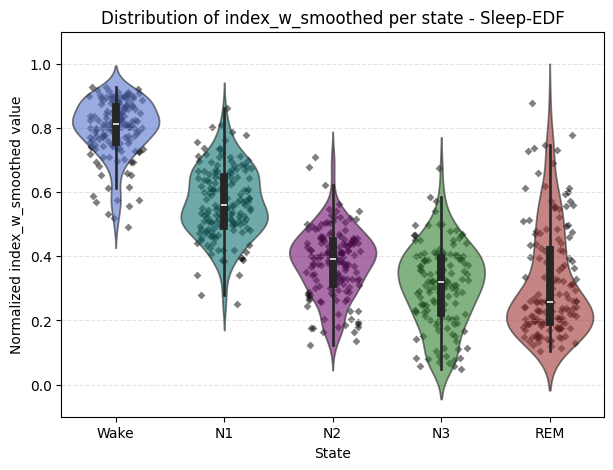

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


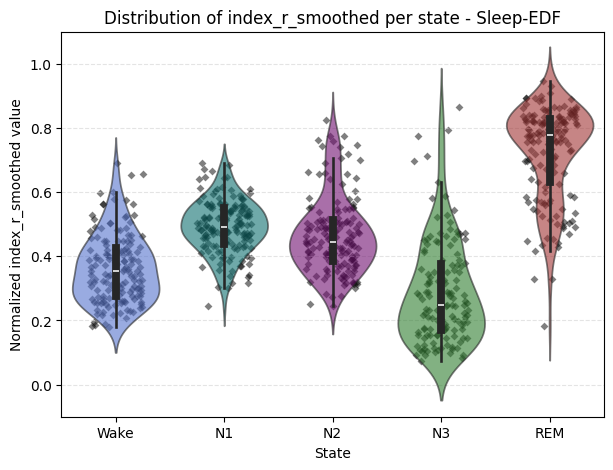

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


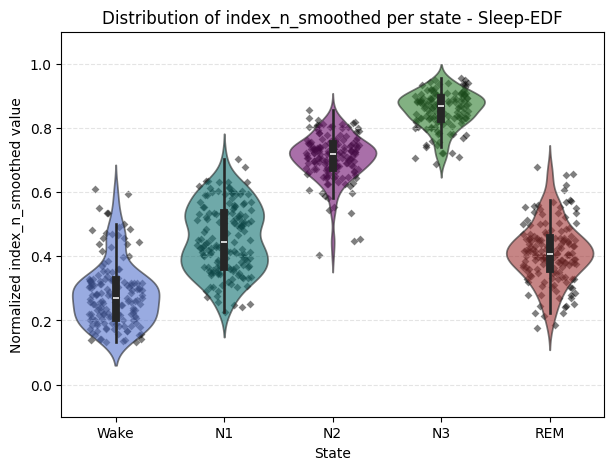

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


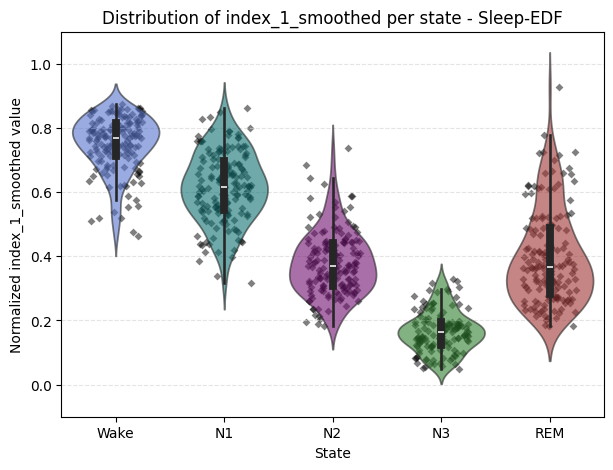

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


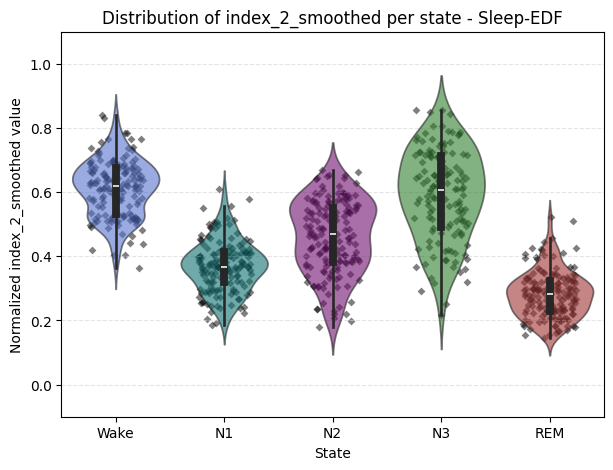

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


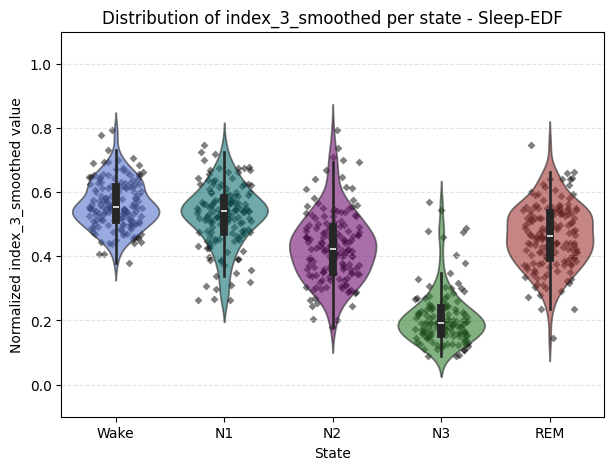

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


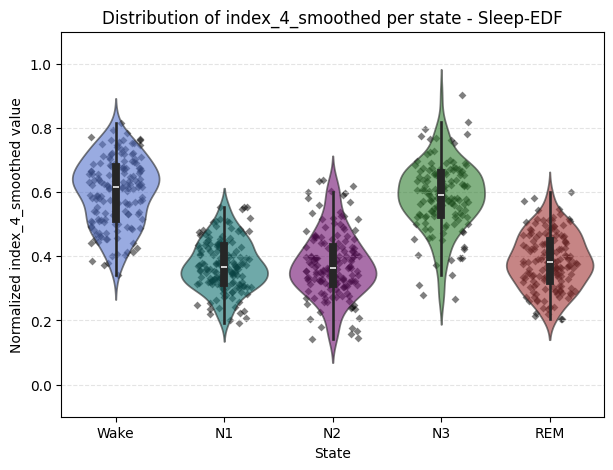

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


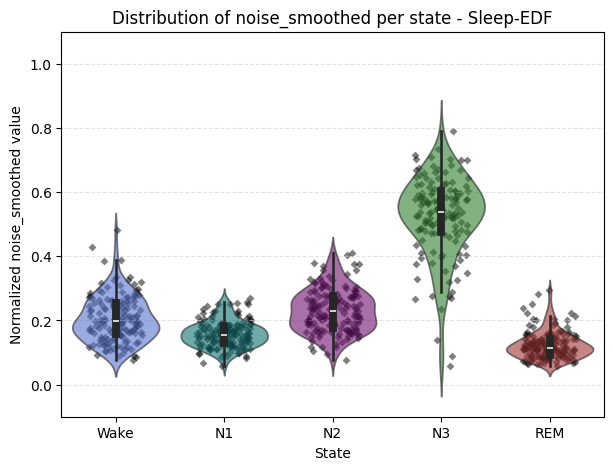

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


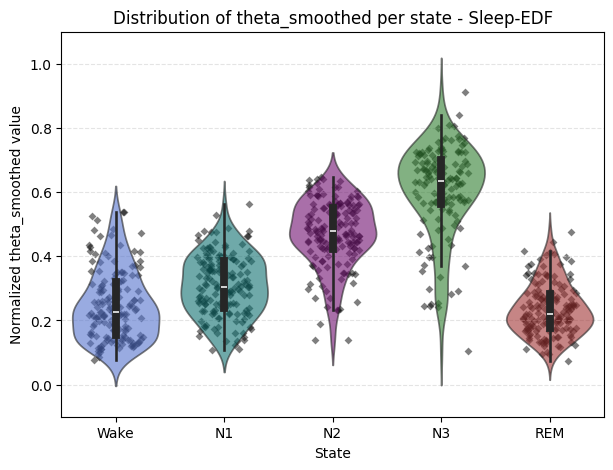

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


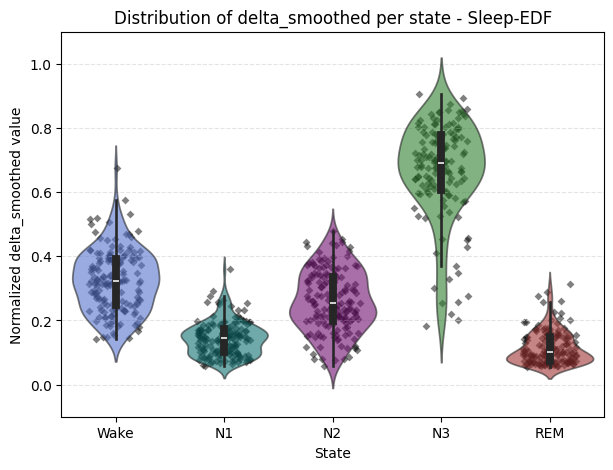

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


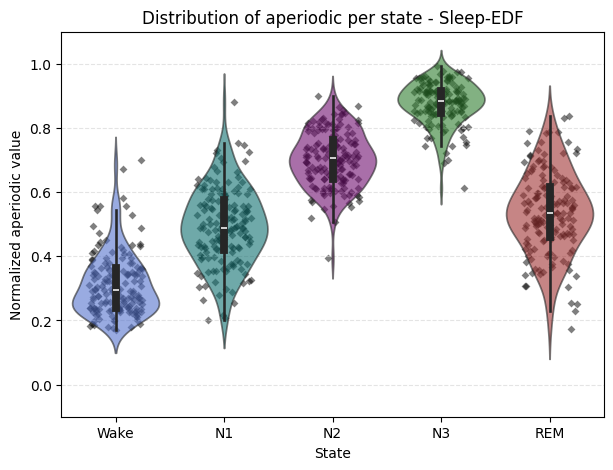

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


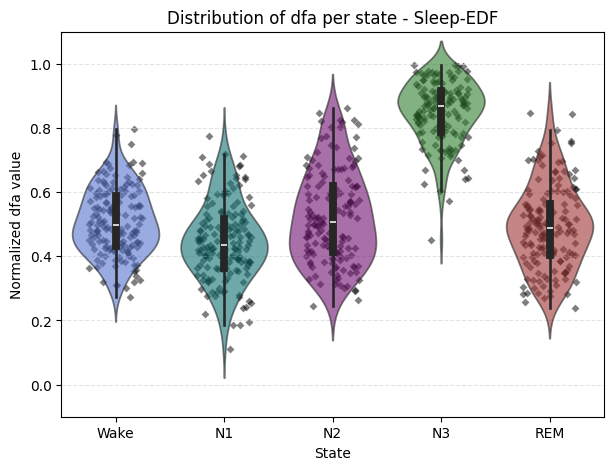

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


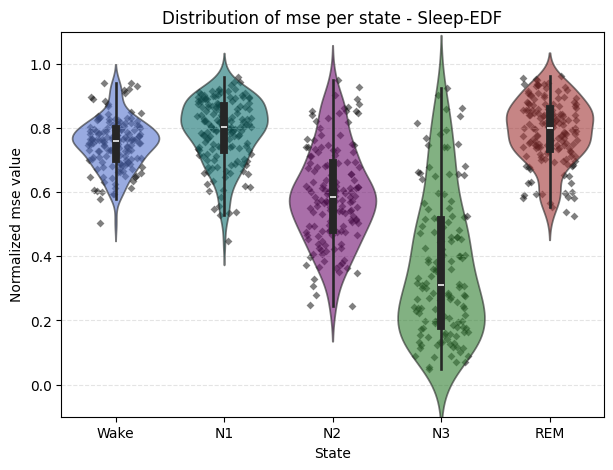

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\1046322526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='State', y='Value', data=df, palette=colors, alpha=0.6, zorder=2)


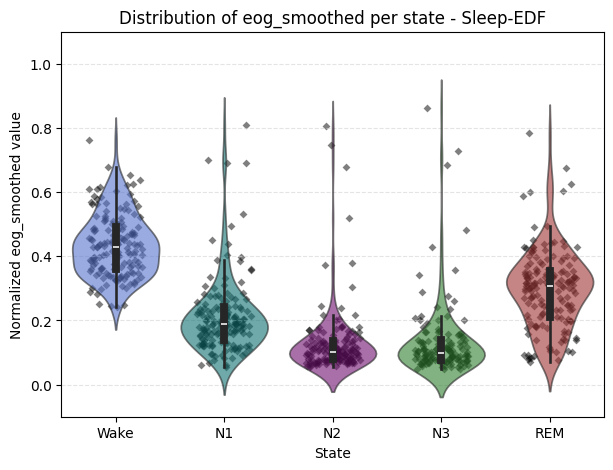

In [30]:
# iterate features
for f_name, f_index in feature_dict.items():
    # get values from dictionary per feature
    df_feat = df[df["Feature"] == f_name]
    # violin visualization function
    features_violin(df_feat, f_name, wanted_keys, state_names, colors, title_id, file_id)

#### Barplots

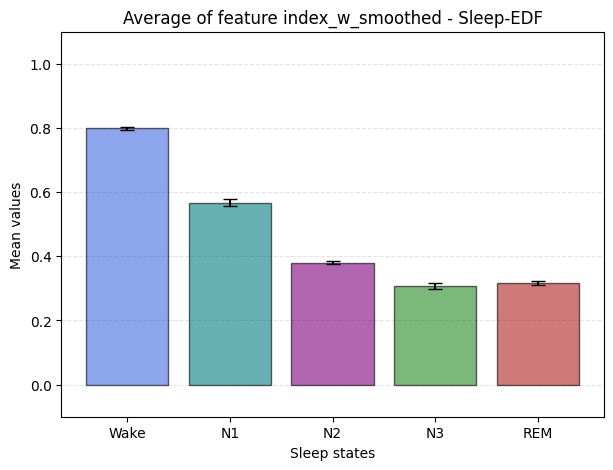

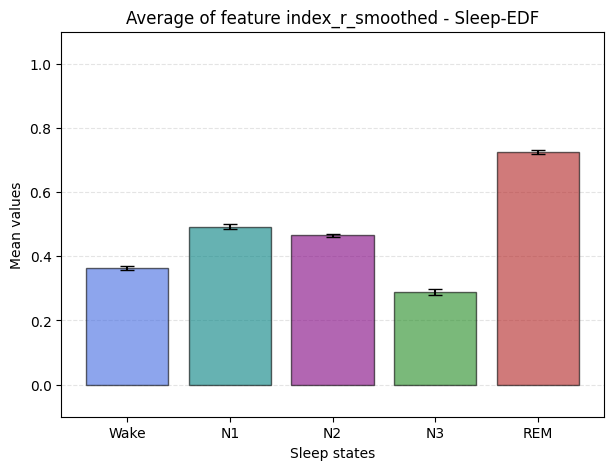

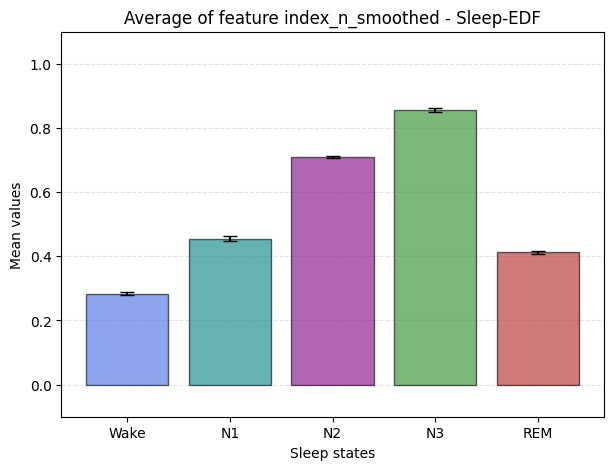

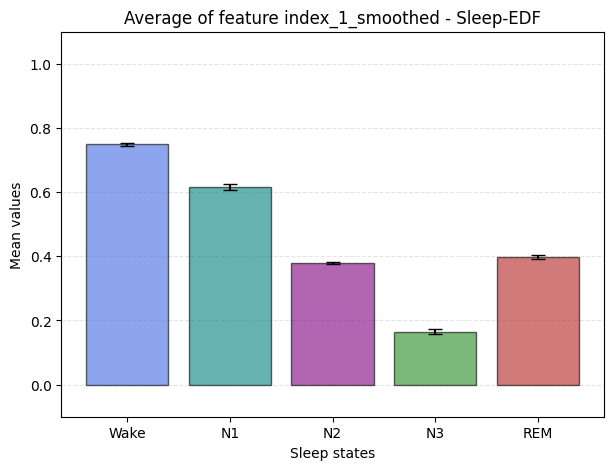

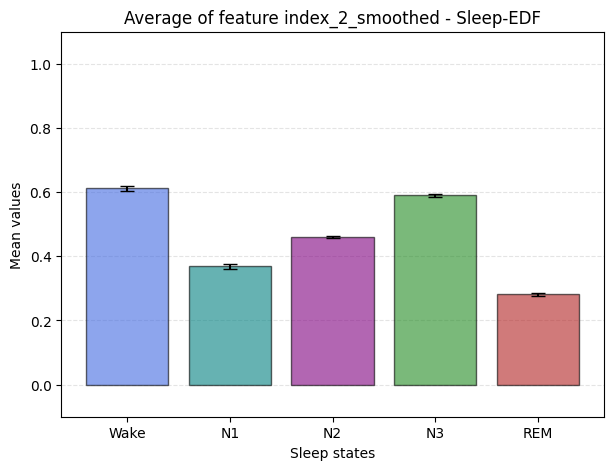

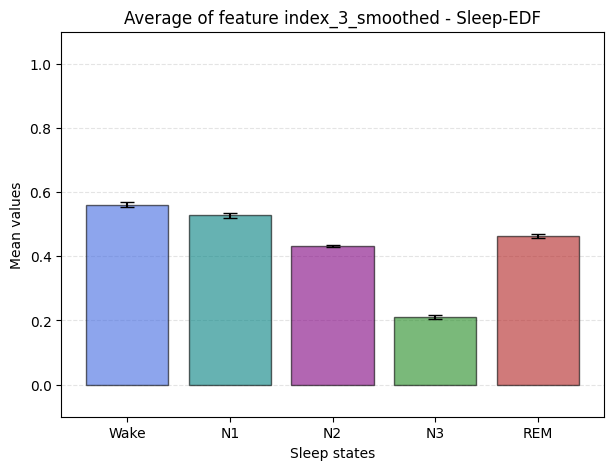

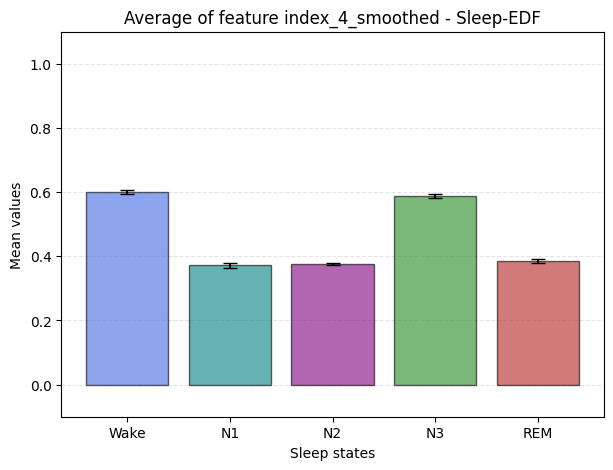

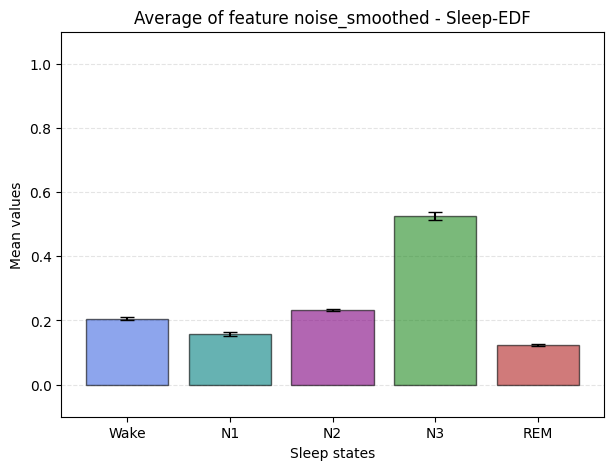

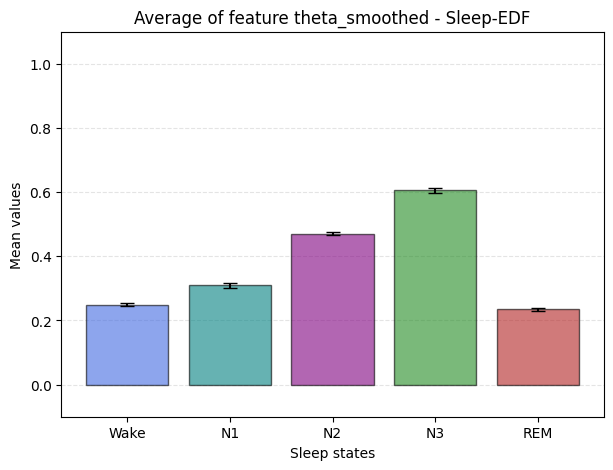

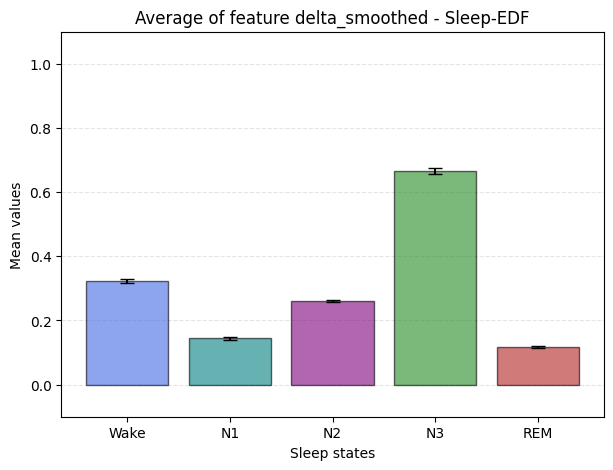

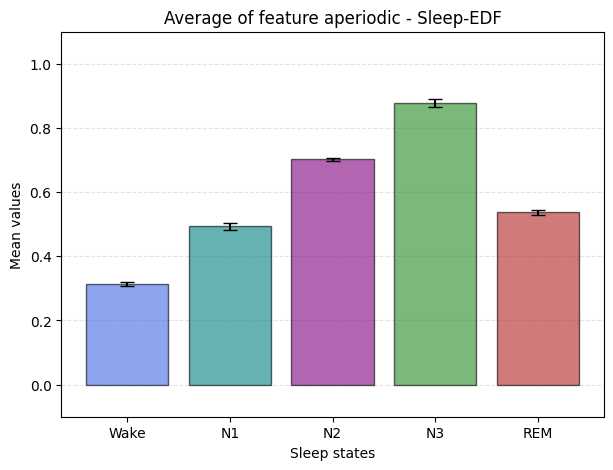

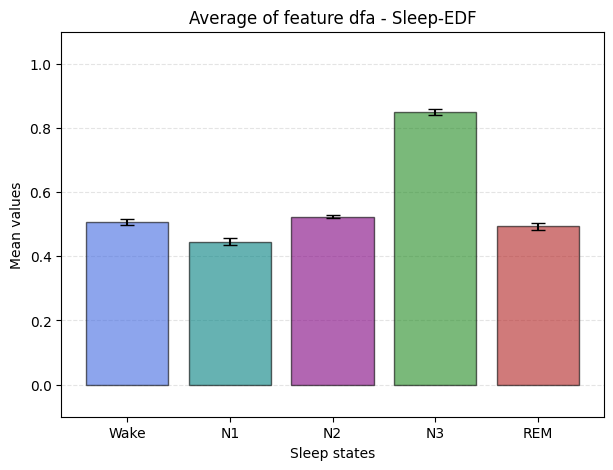

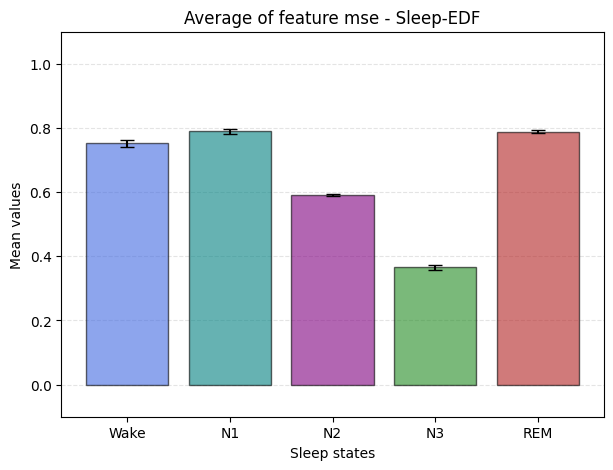

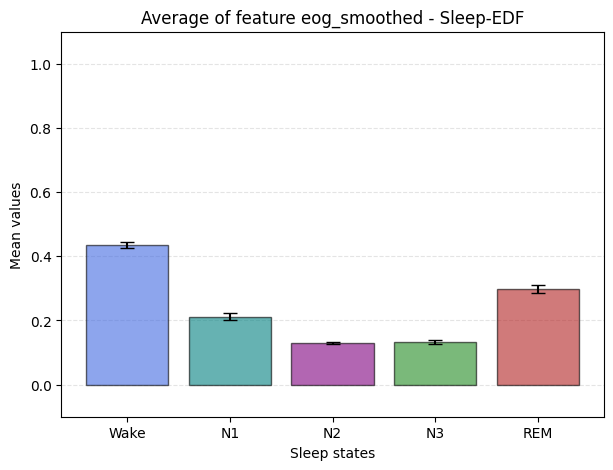

In [ ]:
# iterate features
for f_name, f_index in feature_dict.items():
    # barplot visualization function
    visualize_features(total_average, total_sem, f_name, f_index, title_id, file_id)

# Feature visualization for thesis

### Functions for visualization of rodent features

##### time plots

In [33]:
def time_rodent_features(
    features, 
    states, 
    subject,
    colors=["#0072B2", '#E69F00', '#009E73', '#56B4E9']
):
    # create general variables
    times = np.arange(0, len(features))
    x_times = times * 10 / 60

    # initiate plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        4, 
        1, 
        sharex=True, 
        figsize = (28, 15), 
        constrained_layout=True
    )

    ### plot features
    # main indices
    ax1.plot(
        x_times, 
        features[:, 0].flatten(), 
        label='Index W', 
        color=colors[0]
    )
    ax1.plot(
        x_times, 
        features[:, 2].flatten(), 
        label='Index N', 
        color=colors[2]
    )
    ax1.plot(
        x_times, 
        features[:, 1].flatten(), 
        label='Index R', 
        color=colors[1]
    )

    # extra indices
    ax2.plot(
        x_times, 
        features[:, 3].flatten(), 
        label='Index 1', 
        color=colors[0]
    )
    ax2.plot(
        x_times, 
        features[:, 4].flatten(), 
        label='Index 2', 
        color=colors[1]
    )
    ax2.plot(
        x_times, 
        features[:, 5].flatten(), 
        label='Index 3', 
        color=colors[2]
    )
    ax2.plot(
        x_times, 
        features[:, 6].flatten(), 
        label='Index 4', 
        color=colors[3]
    )

    # spectral powers
    ax3.plot(x_times, features[:, 7].flatten(), label='Noise', color=colors[0])
    ax3.plot(x_times, features[:, 8].flatten(), label='Delta', color=colors[1])
    ax3.plot(x_times, features[:, 9].flatten(), label='Theta', color=colors[2])

    # hypnogram
    ax4.plot(x_times, states, label='Hypnogram')

    ### layout
    # add legends
    ax1.legend(fontsize=13, loc="upper right")
    ax2.legend(fontsize=13, loc="upper right")
    ax3.legend(fontsize=13, loc="upper right")

    # add titles
    ax1.set_title(f"Main indices", fontsize=16)
    ax2.set_title(f"Extra indices", fontsize=16)
    ax3.set_title(f"Spectral powers", fontsize=16)
    ax4.set_title(f"Hypnogram", fontsize=16)
    fig.suptitle(
        f"Rodent features over time - Subject: {subject}", 
        fontsize=18, 
        fontweight="bold"
    )

    # set y ticks
    ax1.set_ylabel("Normalized feature values", fontsize=14)
    ax2.set_ylabel("Normalized feature values", fontsize=14)
    ax3.set_ylabel("Normalized feature values", fontsize=14)
    ax4.set_ylabel("Sleep states", fontsize=14)
    ax4.set_yticks(
        ticks=[0, 1, 2, 3, 4], 
        labels=["Wake", "N1", "N2", "N3", "REM"], 
        fontsize=12
    )
    ax4.invert_yaxis()

    ax4.set_xlabel("Time (minutes)", fontsize=14)
    ax4.tick_params(axis="y", labelsize=12)

    ax1.grid(axis="y")
    ax1.set_axisbelow(True)
    ax2.grid(axis="y")
    ax2.set_axisbelow(True)
    ax3.grid(axis="y")
    ax3.set_axisbelow(True)
    ax4.grid(axis="y")
    ax4.set_axisbelow(True)

    _, end = ax1.get_xlim()
    margin = 6
    ax1.set_xlim(0, end+margin)
    ax2.set_xlim(0, end+margin)
    ax3.set_xlim(0, end+margin)
    ax4.set_xlim(0, end+margin)
    ### ChatGPT prompt: "fig.suptitle overlapping axis1 title"
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # save figure as svg
    plt.savefig(
        os.path.join(output, f"{file_id}_rodent_features-over-time-{subject}.svg"), 
        format="svg"
    )

    # Show the plots
    plt.show()


##### bar plots

In [34]:
def bar_rodent_features(
    average_dict, 
    sem_dict, 
    bar_width=0.2,
    categories=['Wake', 'N1', "N2", "N3", 'REM'], 
    hatches=["///", "---", "xxx", "..."],
    colors=["#0072B2", '#E69F00', '#009E73', '#56B4E9'],
    title_extension="All subjects"
):
    # create the x-axis
    x=np.arange(len(categories))

    # initiate plot
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharex=True, figsize = (28, 6))

    ### main indices
    values_w = [feature[0] for feature in average_dict.values()]
    sem_w = [feature[0] for feature in sem_dict.values()]
    values_r = [feature[1] for feature in average_dict.values()]
    sem_r = [feature[1] for feature in sem_dict.values()]
    values_n = [feature[2] for feature in average_dict.values()]
    sem_n = [feature[2] for feature in sem_dict.values()]
    # Create bar plots
    main_labels = ["Index W", "Index R", "Index N"]
    # index w hatch
    ax1.bar(
        x - bar_width, 
        values_w, 
        width=bar_width, 
        color=colors[0], 
        edgecolor='black', 
        hatch=hatches[0]
    )
    # index w bar
    ax1.bar(
        x - bar_width, 
        values_w, 
        width=bar_width, 
        label='Index W', 
        color=colors[0], 
        yerr=sem_w, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # index r hatch
    ax1.bar(
        x, 
        values_r, 
        width=bar_width, 
        color=colors[1], 
        edgecolor='black', 
        hatch=hatches[1]
    )
    # index r bar
    ax1.bar(
        x, 
        values_r, 
        width=bar_width, 
        label='Index R', 
        color=colors[1], 
        yerr=sem_r, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # index n hatch
    ax1.bar(
        x  + bar_width, 
        values_n, 
        width=bar_width, 
        color=colors[2], 
        edgecolor='black', 
        hatch=hatches[2]
    )
    # index n bar
    ax1.bar(
        x + bar_width, 
        values_n, 
        width=bar_width, 
        label='Index N', 
        color=colors[2], 
        yerr=sem_n, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    ### extra indices
    values_1 = [feature[3] for feature in average_dict.values()]
    sem_1 = [feature[3] for feature in sem_dict.values()]
    values_2 = [feature[4] for feature in average_dict.values()]
    sem_2 = [feature[4] for feature in sem_dict.values()]
    values_3 = [feature[5] for feature in average_dict.values()]
    sem_3 = [feature[5] for feature in sem_dict.values()]
    values_4 = [feature[6] for feature in average_dict.values()]
    sem_4 = [feature[6] for feature in sem_dict.values()]
    # Create bar plots
    extra_labels = ["Index 1", "Index 2", "Index 3", "Index 4"]
    # index 1 hatch
    ax2.bar(
        x  - (1.5*bar_width), 
        values_1, 
        width=bar_width, 
        color=colors[0], 
        edgecolor='black', 
        hatch=hatches[0]
    )
    # index 1 bar
    ax2.bar(
        x - (1.5*bar_width), 
        values_1, 
        width=bar_width, 
        label='Index 1', 
        color=colors[0], 
        yerr=sem_1, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # index 2 hatch
    ax2.bar(
        x  - (0.5*bar_width), 
        values_2, 
        width=bar_width, 
        color=colors[1], 
        edgecolor='black', 
        hatch=hatches[1]
    )
    # index 2 bar
    ax2.bar(
        x - (0.5*bar_width), 
        values_2, 
        width=bar_width, 
        label='Index 2', 
        color=colors[1], 
        yerr=sem_2, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # index 3 hatch
    ax2.bar(
        x  + (0.5*bar_width), 
        values_3, 
        width=bar_width, 
        color=colors[2], 
        edgecolor='black', 
        hatch=hatches[2]
    )
    # index 3 bar
    ax2.bar(
        x + (0.5*bar_width), 
        values_3, 
        width=bar_width, 
        label='Index 3', 
        color=colors[2], 
        yerr=sem_3, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # index 4 hatch
    ax2.bar(
        x  + (1.5*bar_width), 
        values_4, 
        width=bar_width, 
        color=colors[3], 
        edgecolor='black', 
        hatch=hatches[3]
    )
    # index 4 bar
    ax2.bar(
        x + (1.5*bar_width), 
        values_4, 
        width=bar_width, 
        label='Index 4', 
        color=colors[3], 
        yerr=sem_4, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    ### spectral powers
    values_noise = [feature[7] for feature in average_dict.values()]
    sem_noise = [feature[7] for feature in sem_dict.values()]
    values_delta = [feature[8] for feature in average_dict.values()]
    sem_delta = [feature[8] for feature in sem_dict.values()]
    values_theta = [feature[9] for feature in average_dict.values()]
    sem_theta = [feature[9] for feature in sem_dict.values()]
    # Create bar plots
    psd_labels = ["Noise", "Delta", "Theta"]
    # noise hatch
    ax3.bar(
        x  - bar_width, 
        values_noise, 
        width=bar_width, 
        color=colors[0], 
        edgecolor='black', 
        hatch=hatches[0]
    )
    # noise bar
    ax3.bar(
        x - bar_width, 
        values_noise, 
        width=bar_width, 
        label='Noise', 
        color=colors[0], 
        yerr=sem_noise, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # delta hatch
    ax3.bar(
        x, 
        values_delta, 
        width=bar_width, 
        color=colors[1], 
        edgecolor='black', 
        hatch=hatches[1]
    )
    # delta bar
    ax3.bar(
        x, 
        values_delta, 
        width=bar_width, 
        label='Delta', 
        color=colors[1], 
        yerr=sem_delta, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # theta hatch
    ax3.bar(
        x  + bar_width, 
        values_theta, 
        width=bar_width, 
        color=colors[2], 
        edgecolor='black', 
        hatch=hatches[2]
    )
    # theta bar
    ax3.bar(
        x + bar_width, 
        values_theta, 
        width=bar_width, 
        label='Theta', 
        color=colors[2], 
        yerr=sem_theta, 
        capsize=5, 
        edgecolor='black', 
        error_kw=dict(elinewidth=2, capthick=2),
        alpha=0.8
    )

    # set axis labels
    ax1.set_xlabel('Sleep stages', fontsize=14)
    ax2.set_xlabel('Sleep stages', fontsize=14)
    ax3.set_xlabel('Sleep stages', fontsize=14)
    ax1.set_ylabel('Normalized feature values', fontsize=14)
    ax2.set_ylabel('Normalized feature values', fontsize=14)
    ax3.set_ylabel('Normalized feature values', fontsize=14)

    # set static plot size
    ax1.set_ylim(0, 1)
    ax2.set_ylim(0, 1)
    ax3.set_ylim(0, 1)

    # set plot titles
    ax1.set_title("Main indices", fontsize=16)
    ax2.set_title("Extra indices", fontsize=16)
    ax3.set_title("Spectral powers", fontsize=16)
    fig.suptitle(
        f"Rodent feature distribution across sleep states (Mean ± SEM) "
        f"- {title_extension}", 
        fontsize=18, 
        fontweight="bold"
    )

    # set tick parameters
    ax1.set_xticks(x, categories, fontsize=12)
    ax2.set_xticks(x, categories, fontsize=12)
    ax3.set_xticks(x, categories, fontsize=12)
    ax1.tick_params(axis="y", labelsize=12)
    ax2.tick_params(axis="y", labelsize=12)
    ax3.tick_params(axis="y", labelsize=12)

    # annotate bars
    for i in range(len(categories)):
        ax1.text(
            x[i] - bar_width, 
            values_w[i] + 0.02, 
            str(round(values_w[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax1.text(
            x[i], 
            values_r[i] + 0.02, 
            str(round(values_r[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax1.text(
            x[i] + bar_width, 
            values_n[i] + 0.02, 
            str(round(values_n[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )

    for i in range(len(categories)):
        ax2.text(
            x[i] - (1.5*bar_width), 
            values_1[i] + 0.02, 
            str(round(values_1[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax2.text(
            x[i] - (0.5*bar_width), 
            values_2[i] + 0.02, 
            str(round(values_2[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax2.text(
            x[i] + (0.5*bar_width), 
            values_3[i] + 0.02, 
            str(round(values_3[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax2.text(
            x[i] + (1.5*bar_width), 
            values_4[i] + 0.02, 
            str(round(values_4[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )

    for i in range(len(categories)):
        ax3.text(
            x[i] - bar_width, 
            values_noise[i] + 0.02, 
            str(round(values_noise[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax3.text(
            x[i], 
            values_delta[i] + 0.02, 
            str(round(values_delta[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )
        ax3.text(
            x[i] + bar_width, 
            values_theta[i] + 0.02, 
            str(round(values_theta[i], 2)), 
            ha='center', 
            va='bottom', 
            fontsize=12
        )

    # create legends
    handles = [Patch(facecolor=c, edgecolor="#444444", hatch=h, label=l)
            for c, h, l in zip(colors, hatches, main_labels)]
    ax1.legend(handles=handles, loc='upper right', fontsize=13)
    handles = [Patch(facecolor=c, edgecolor="#444444", hatch=h, label=l)
            for c, h, l in zip(colors, hatches, extra_labels)]
    ax2.legend(handles=handles, loc='upper right', fontsize=13)
    handles = [Patch(facecolor=c, edgecolor="#444444", hatch=h, label=l)
            for c, h, l in zip(colors, hatches, psd_labels)]
    ax3.legend(handles=handles, loc='upper right', fontsize=13)

    # create grids below bars
    ax1.grid(axis="y")
    ax1.set_axisbelow(True)
    ax2.grid(axis="y")
    ax2.set_axisbelow(True)
    ax3.grid(axis="y")
    ax3.set_axisbelow(True)

    # create extra space for title
    plt.tight_layout(rect=[0, 0, 1, 0.99])

    # save the figure as svg
    plt.savefig(
        os.path.join(
            output, 
            f"{file_id}rodent-feature-indices-barplot-{title_extension}.svg"
        ), 
        format="svg"
    )

    plt.show()

### Function for visualization of new features

##### time plots

In [35]:
def time_new_features(
    features, 
    states, 
    subject, 
    colors=["#0072B2", '#E69F00', '#009E73', '#56B4E9']
):
    # create general variables
    times = np.arange(0, len(features))
    x_times = times * 10 / 60

    # initiate plot
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
        5, 
        1, 
        sharex=True, 
        figsize = (28, 19), 
        constrained_layout=True
    )

    ### plot features
    # main indices
    ax1.plot(
        x_times, 
        features[:, 10].flatten(), 
        label='AE', 
        color=colors[0]
    )
    ax2.plot(
        x_times, 
        features[:, 11].flatten(), 
        label='DFA', 
        color=colors[1]
    )
    ax3.plot(
        x_times, 
        features[:, 12].flatten(), 
        label='MSE', 
        color=colors[2]
    )
    ax4.plot(
        x_times,
        features[:, 13].flatten(),
        label="EOG",
        color=colors[3]
    )

    # hypnogram
    ax5.plot(x_times, states, label='Hypnogram')

    ### layout
    # add legends
    ax1.legend(fontsize=13, loc="upper right")
    ax2.legend(fontsize=13, loc="upper right")
    ax3.legend(fontsize=13, loc="upper right")
    ax4.legend(fontsize=13, loc="upper right")

    # add titles
    ax1.set_title(f"Aperiodic exponent", fontsize=16)
    ax2.set_title(f"DFA", fontsize=16)
    ax3.set_title(f"MSE", fontsize=16)
    ax4.set_title(f"EOG", fontsize=16)
    ax5.set_title(f"Hypnogram", fontsize=16)
    fig.suptitle(
        f"New features over time - Subject: {subject}", 
        fontsize=18, 
        fontweight="bold"
    )

    # set y ticks
    ax1.set_ylabel("Normalized feature values", fontsize=14)
    ax2.set_ylabel("Normalized feature values", fontsize=14)
    ax3.set_ylabel("Normalized feature values", fontsize=14)
    ax4.set_ylabel("Normalized feature values", fontsize=14)
    ax5.set_ylabel("Sleep states", fontsize=14)
    ax5.set_yticks(
        ticks=[0, 1, 2, 3, 4], 
        labels=["Wake", "N1", "N2", "N3", "REM"], 
        fontsize=12
    )
    ax5.invert_yaxis()

    ax5.set_xlabel("Time (minutes)", fontsize=14)
    ax5.tick_params(axis="y", labelsize=12)

    ax1.grid(axis="y")
    ax1.set_axisbelow(True)
    ax2.grid(axis="y")
    ax2.set_axisbelow(True)
    ax3.grid(axis="y")
    ax3.set_axisbelow(True)
    ax4.grid(axis="y")
    ax4.set_axisbelow(True)
    ax5.grid(axis="y")
    ax5.set_axisbelow(True)

    _, end = ax1.get_xlim()
    margin = 6
    ax1.set_xlim(0, end+margin)
    ax2.set_xlim(0, end+margin)
    ### ChatGPT prompt: "fig.suptitle overlapping axis1 title"
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    # save figure as svg
    plt.savefig(
        os.path.join(
            output, 
            f"{file_id}_new_features-over-time-{subject}.svg"
        ), 
        format="svg"
    )

    # Show the plots
    plt.show()


##### bar plots

In [36]:
def bar_new_features(
    average_dict, 
    sem_dict, 
    bar_width=0.2,
    categories=['Wake', 'N1', "N2", "N3", 'REM'], 
    hatches=["///", "---", "xxx", "..."],
    colors=["#0072B2", '#E69F00', '#009E73', '#56B4E9'],
    title_extension="All subjects"
):
    # initiate plot
    fig, (ax1) = plt.subplots(
        1, 
        1, 
        sharex=True, 
        figsize = (8, 6), 
        constrained_layout=True
    )

    x = np.arange(len(categories))

    # new indices
    values_a = [feature[10] for feature in average_dict.values()]
    sem_d = [feature[10] for feature in sem_dict.values()]
    values_m = [feature[11] for feature in average_dict.values()]
    sem_a = [feature[11] for feature in sem_dict.values()]
    values_d = [feature[12] for feature in average_dict.values()]
    sem_m = [feature[12] for feature in sem_dict.values()]
    values_e = [feature[13] for feature in average_dict.values()]
    sem_e = [feature[13] for feature in sem_dict.values()]
    ### Create bar plots
    labels = ["AE", "DFA", "MSE", "EOG"]
    # aperiodic exponent hatch
    ax1.bar(
    x - (1.5*bar_width), 
    values_a, 
    width=bar_width, 
    color=colors[0], 
    edgecolor='black', 
    hatch=hatches[0]
    )
    # aperiodic exponent bar
    ax1.bar(
    x - (1.5*bar_width), 
    values_a, 
    width=bar_width, 
    label='AE', 
    color=colors[0], 
    yerr=sem_a, 
    capsize=5, 
    edgecolor='black', 
    error_kw=dict(elinewidth=2, capthick=2),
    alpha=0.8
    )

    # DFA hatch
    ax1.bar(
    x - (0.5*bar_width), 
    values_d, 
    width=bar_width, 
    color=colors[1], 
    edgecolor='black', 
    hatch=hatches[1]
    )
    # DFA bar
    ax1.bar(
    x - (0.5*bar_width), 
    values_d, width=bar_width, 
    label='DFA', 
    color = colors[1], 
    yerr=sem_d, 
    capsize=5, 
    edgecolor='black', 
    error_kw=dict(elinewidth=2, capthick=2),
    alpha=0.8
    )

    # MSE hatch
    ax1.bar(
    x + (0.5*bar_width), 
    values_m, 
    width=bar_width, 
    color=colors[2], 
    edgecolor='black', 
    hatch=hatches[2]
    )
    # MSE bar
    ax1.bar(
    x + (0.5*bar_width), 
    values_m, 
    width=bar_width, 
    color=colors[2], 
    yerr=sem_m, 
    capsize=5, 
    edgecolor='black', 
    error_kw=dict(elinewidth=2, capthick=2),
    alpha=0.8
    )

    # EOG hatch
    ax1.bar(
    x + (1.5*bar_width), 
    values_e, 
    width=bar_width, 
    color=colors[3], 
    edgecolor='black', 
    hatch=hatches[3]
    )
    # EOG bar
    ax1.bar(
    x + (1.5*bar_width), 
    values_e, 
    width=bar_width, 
    label='EOG', 
    color=colors[3], 
    yerr=sem_e, 
    capsize=5, 
    edgecolor='black', 
    error_kw=dict(elinewidth=2, capthick=2), 
    alpha=0.8
    )

    # set axis labels
    ax1.set_xlabel('Sleep stages', fontsize=14)
    ax1.set_ylabel('Normalized feature values', fontsize=14)

    # set static plot size
    ax1.set_ylim(0, 1)

    # set titles
    fig.suptitle(
    f"New features distribution across sleep states (Mean ± SEM) "
    f"- {title_extension}", 
    fontsize=18, 
    fontweight="bold"
    )

    # set tick settings
    ax1.set_xticks(x, categories, fontsize=12)
    ax1.tick_params(axis="y", labelsize=12)

    # annotate bars
    for i in range(len(categories)):
        ax1.text(
                x[i] - (1.5*bar_width), 
                values_a[i] + 0.02, 
                str(round(values_a[i], 2)), 
                ha='center', 
                va='bottom', 
                fontsize=12
        )
        ax1.text(
                x[i] - (0.5*bar_width), 
                values_d[i] + 0.02, 
                str(round(values_d[i], 2)), 
                ha='center', 
                va='bottom', 
                fontsize=12
        )
        ax1.text(
                x[i] + (0.5*bar_width), 
                values_m[i] + 0.02, 
                str(round(values_m[i], 2)), 
                ha='center', 
                va='bottom', 
                fontsize=12
        )
        ax1.text(
                x[i] + (1.5*bar_width), 
                values_e[i] + 0.02, 
                str(round(values_e[i], 2)), 
                ha='center', 
                va='bottom', 
                fontsize=12
        )

    # create legend
    handles = [Patch(facecolor=c, edgecolor="#444444", hatch=h, label=l) 
               for c, h, l in zip(colors, hatches, labels)]
    ax1.legend(handles=handles, loc='upper right', fontsize=13)

    # create grid below bars
    ax1.grid(axis="y")
    ax1.set_axisbelow(True)

    # creates additional space for title
    plt.tight_layout(rect=[0, 0, 1, 0.99])

    # save fig as svg file
    plt.savefig(
        os.path.join(
            output,
            f"{file_id}new-feature-indices-barplot-{title_extension}.svg"
        ), 
        format="svg"
    )

    plt.show()

### Single subject features

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\3054105645.py:123: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.99])


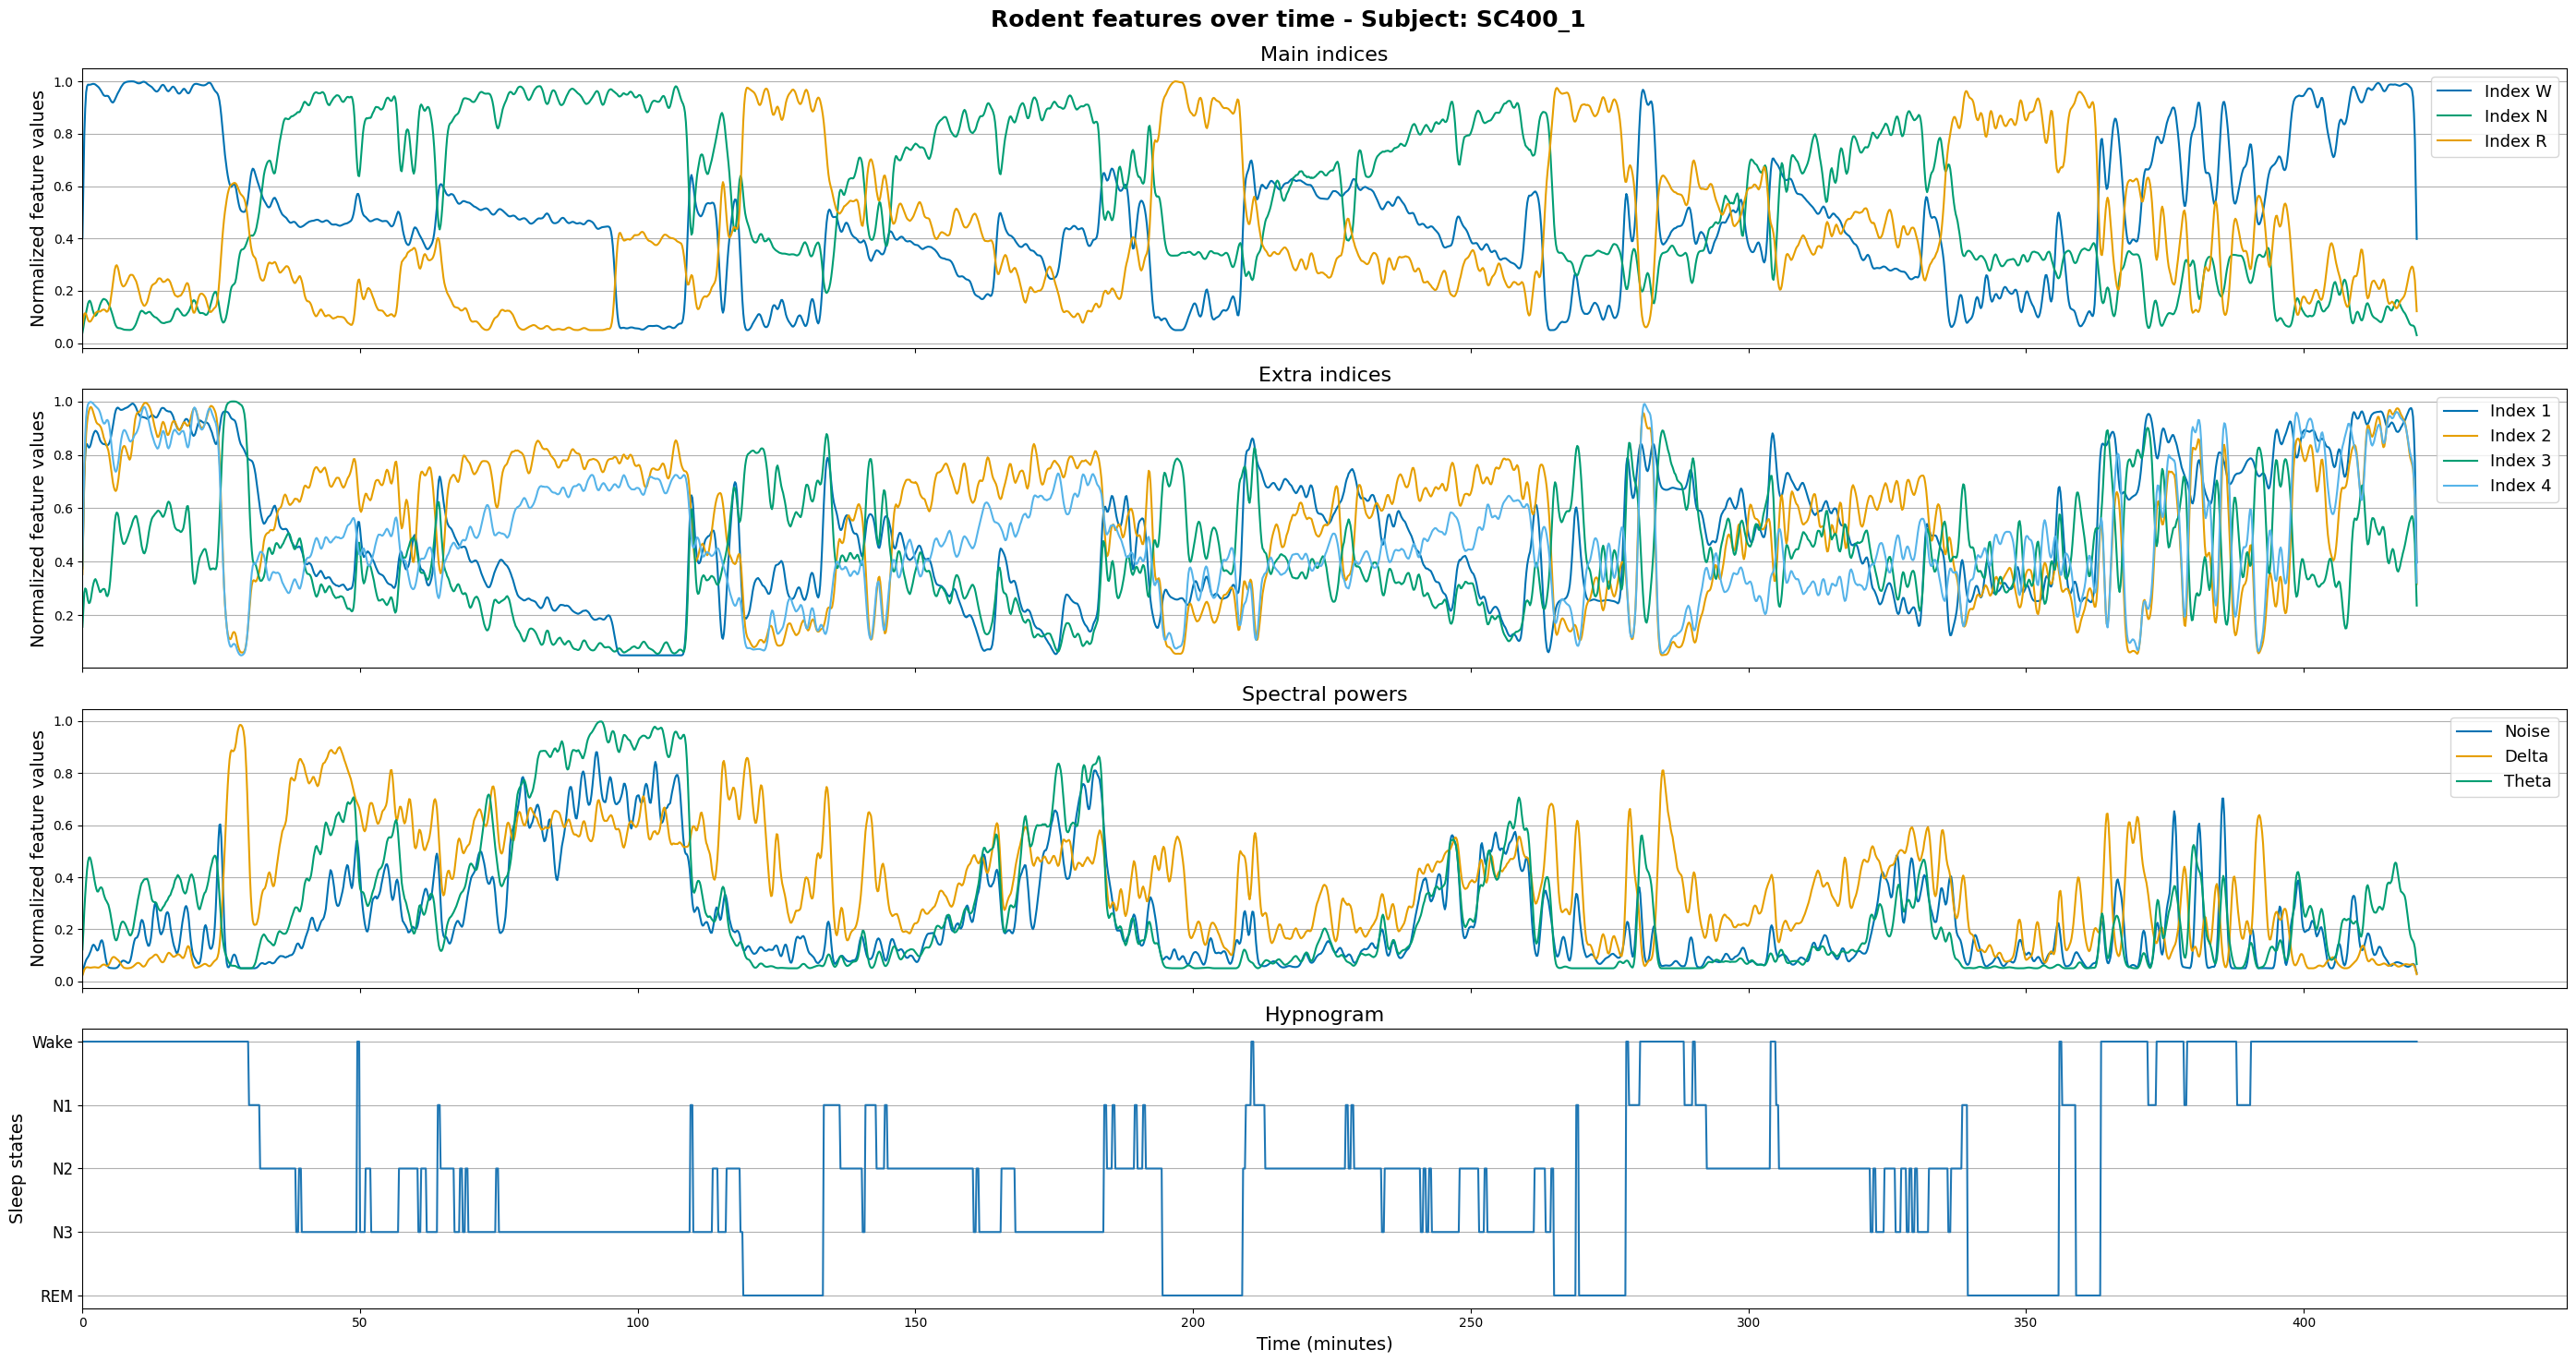

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\3704048707.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.99])


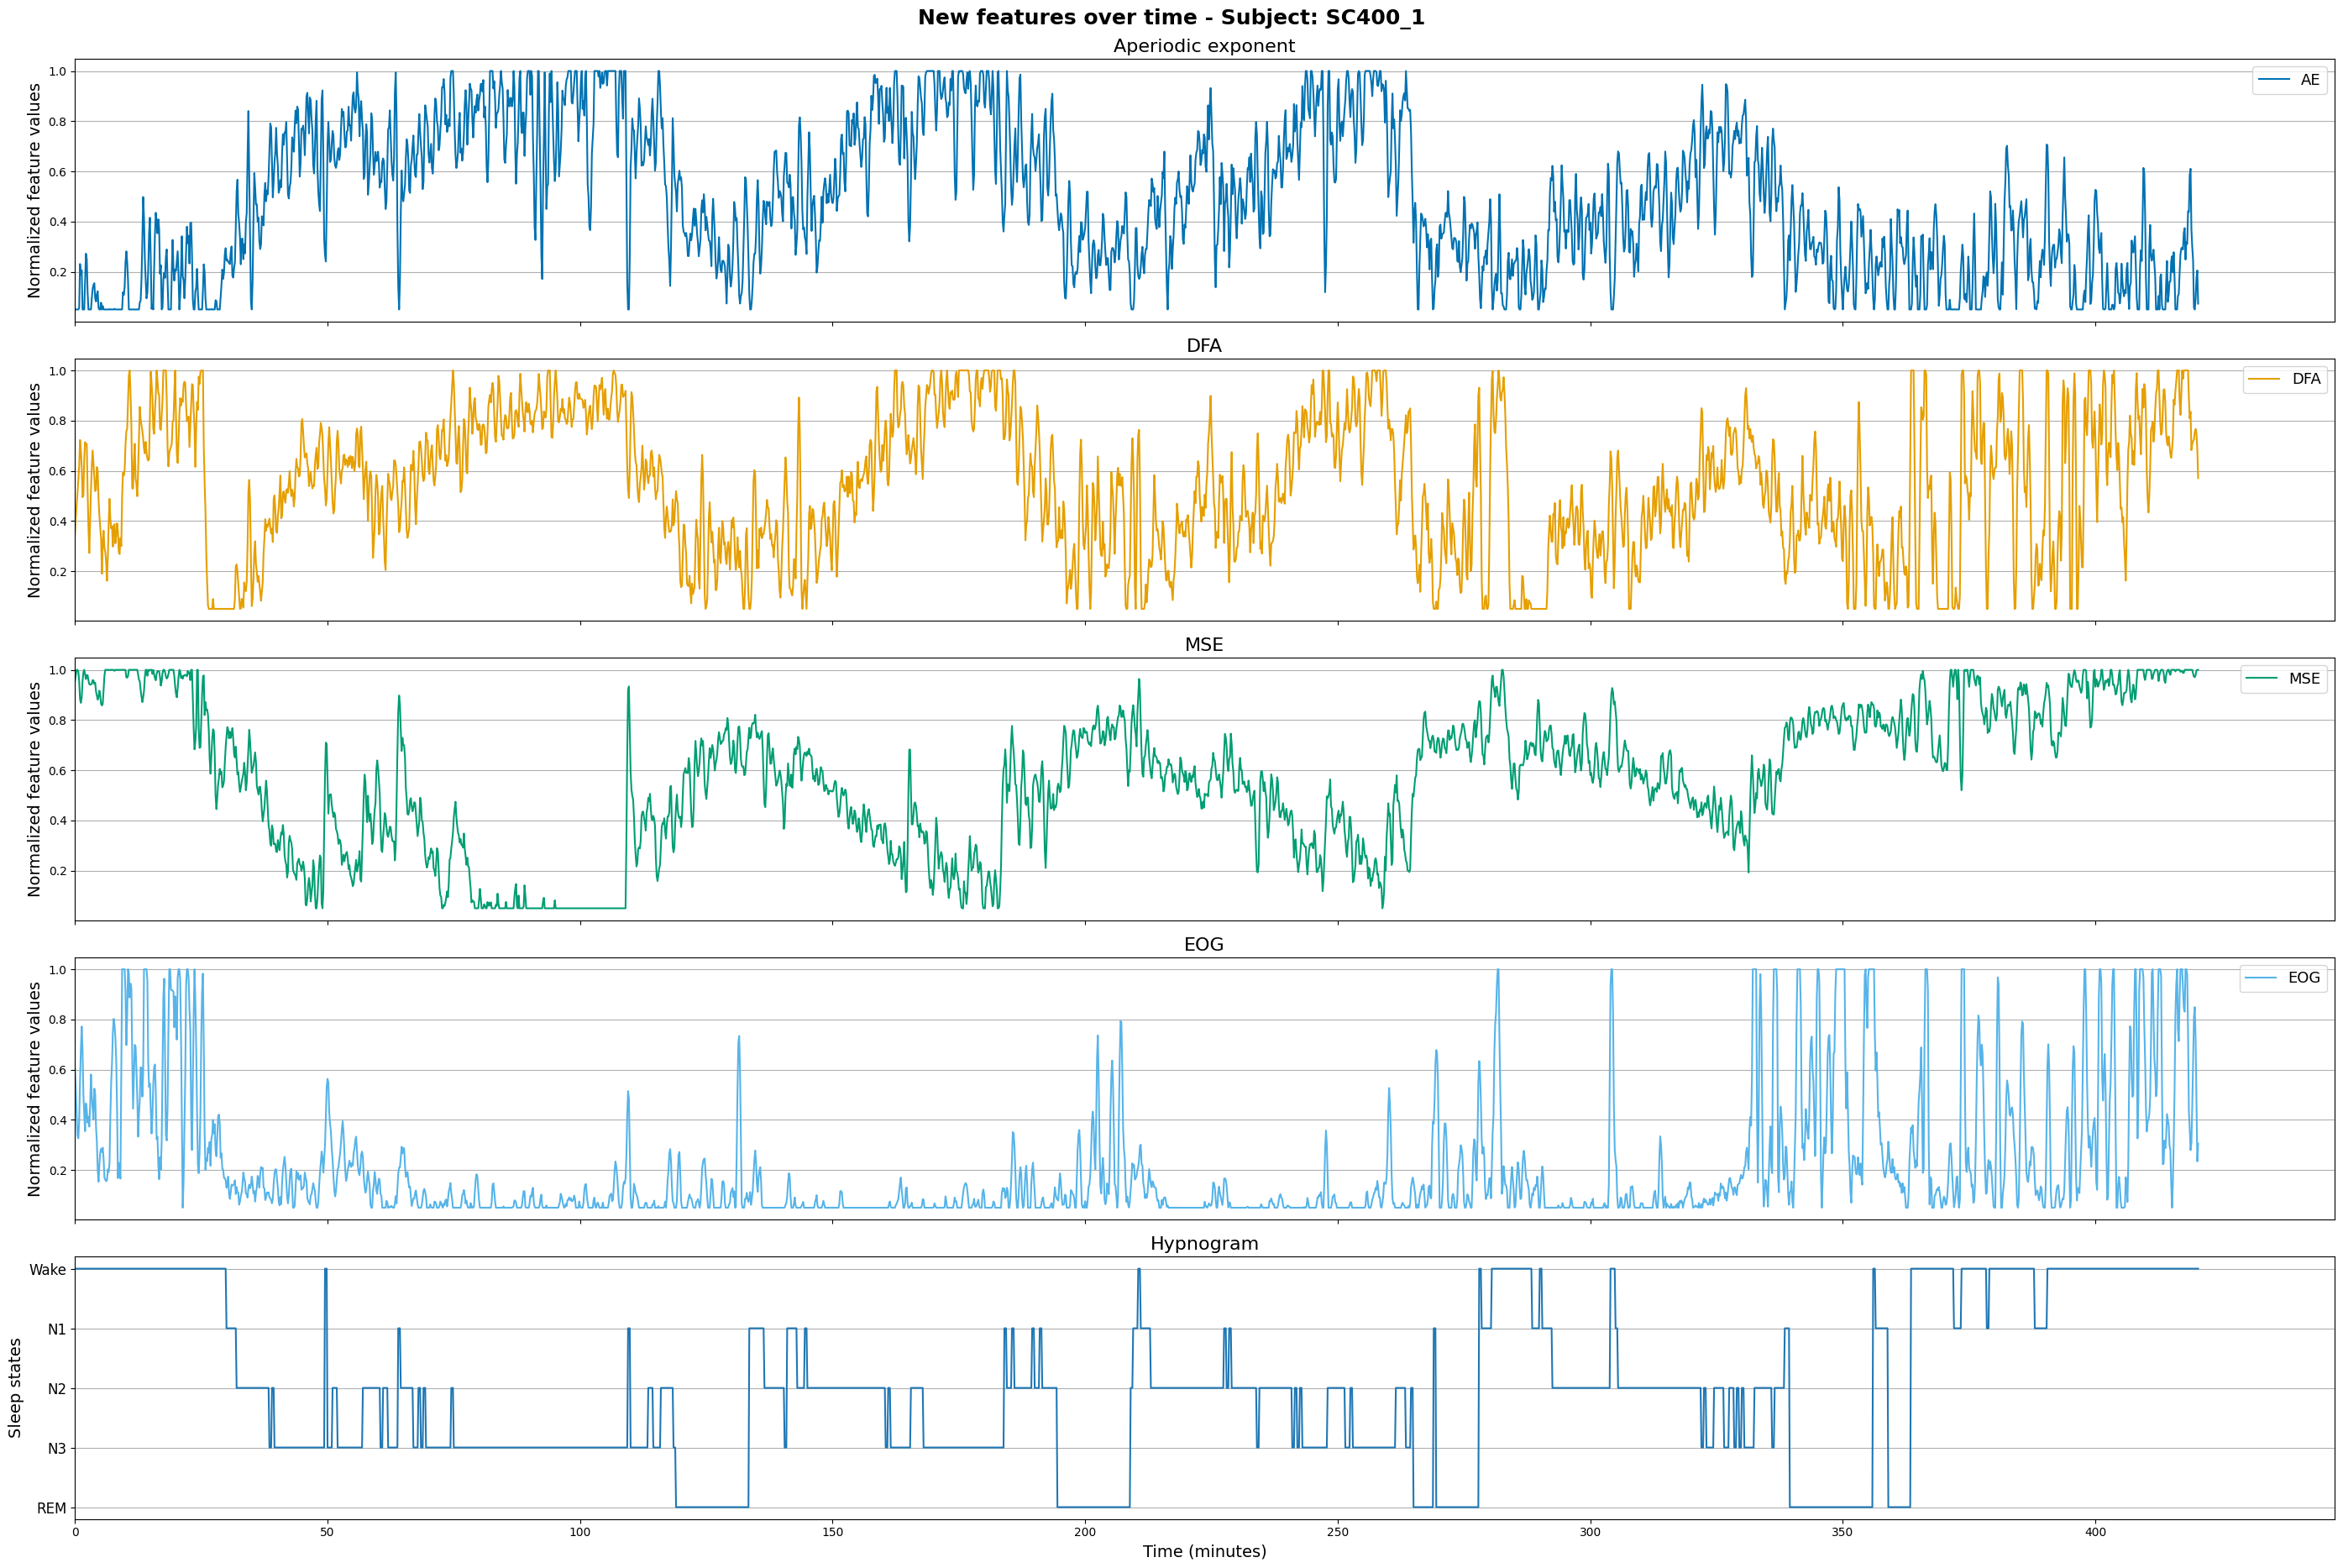

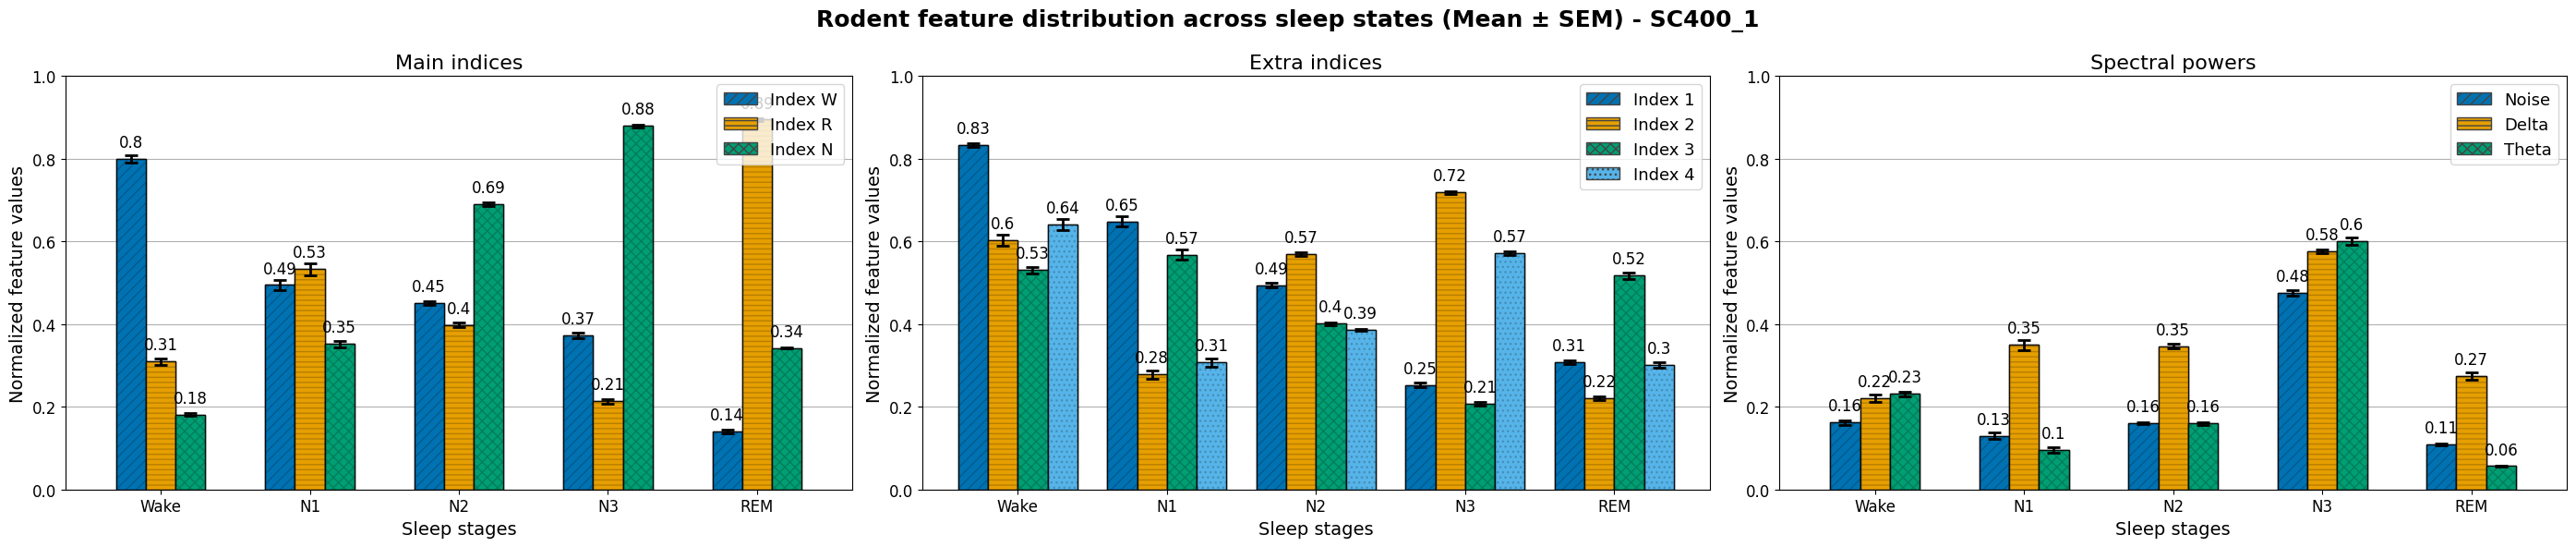

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\2643904612.py:186: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.99])


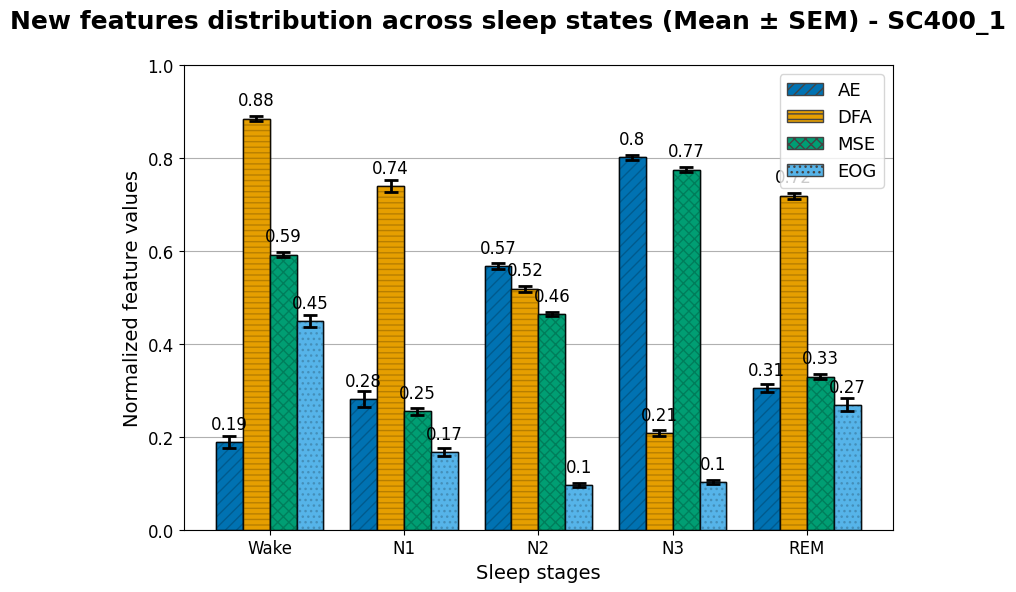

In [37]:
# get subject values
subject = "SC400_1"
features = h5[subject]["Features"][:]
states = h5[subject]["Mapped_scores"][:]

# time plot rodent
time_rodent_features(features, states, subject)
# time plot new
time_new_features(features, states, subject)
# bar plot rodent
bar_rodent_features(
    average_per_state_per_subject[subject], 
    sem_per_state_per_subject[subject], 
    title_extension=subject
)
# bar plot new
bar_new_features(
    average_per_state_per_subject[subject], 
    sem_per_state_per_subject[subject], 
    title_extension=subject
)

### All subjects features

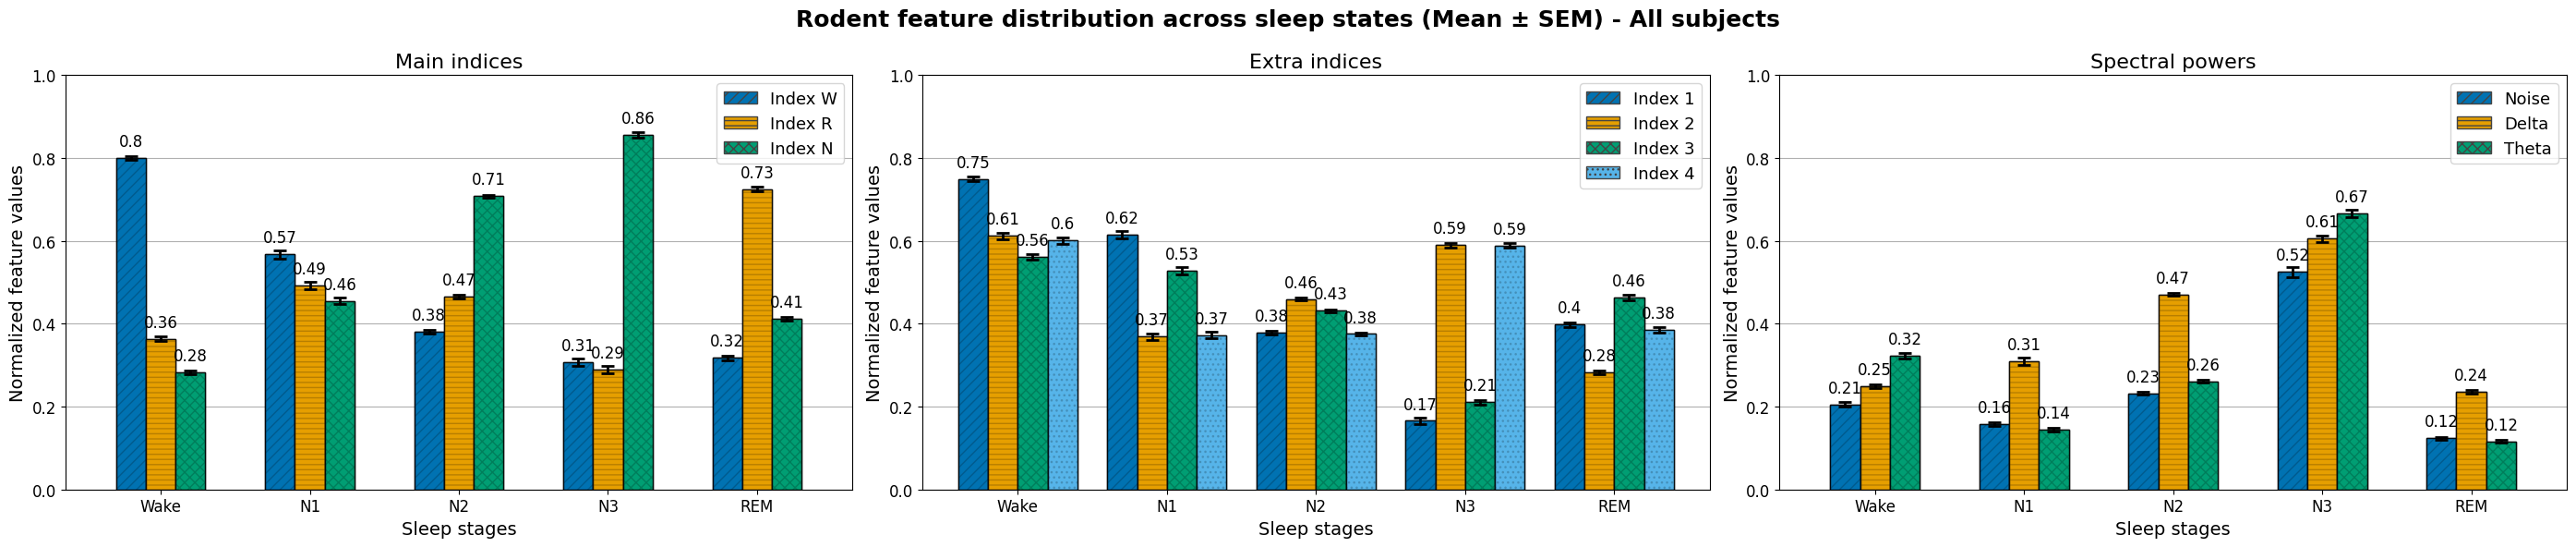

C:\Users\andri\AppData\Local\Temp\ipykernel_9152\2643904612.py:186: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.99])


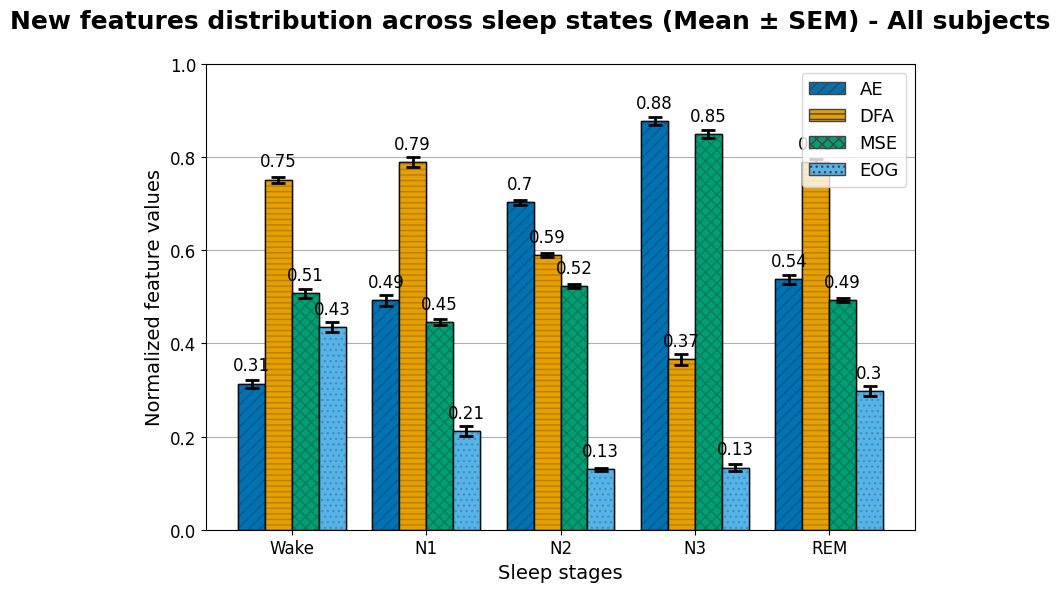

In [38]:
bar_rodent_features(
    total_average, 
    total_sem, 
    title_extension="All subjects"
)
bar_new_features(
    total_average, 
    total_sem, 
    title_extension="All subjects"
)